# Dataset Preprocessing
In this file, we apply the pre-processing pipeline to transform the datasets and create new datasets suitable for training a RUL estimation model.

### 1. Data Importing

The dataset consists of multiple multivariate time series, each representing the operational history of a different engine. These time series are divided into training and test subsets, simulating a fleet of engines of the same type. Each engine starts with a different level of initial wear and manufacturing variation, which is unknown to the user.
In the training set, each engine operates normally at the beginning of its time series and eventually develops a fault. The fault increases in severity until the engine reaches system failure. In the test set, the time series ends some time before failure. After testing, a vector of ground-truth Remaining Useful Life (RUL) values is provided.
There are a total of four datasets, each representing a different operating condition and fault mode combination. For this study, we focus on the FD001 dataset.


In [208]:
train_file_path = 'dataset/train_FD001.txt'
test_file_path = 'dataset/test_FD001.txt'
real_RUL_file_path = 'dataset/RUL_FD001.txt'

In [209]:
column_names = [
    'engine_id', 'cycle',
    'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5',
    'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
    'sensor_21']

In [210]:
import pandas as pd

df_train = pd.read_csv(
        train_file_path,
        sep=r'\s+',    
        header=None,      
        names=column_names 
    )

df_test = pd.read_csv(
        test_file_path,
        sep=r'\s+',    
        header=None,      
        names=column_names 
    )

df_rul = pd.read_csv(
        real_RUL_file_path,
        sep=r'\s+',    
        header=None,      
        names=["RUL"] 
    )

In [211]:
#we add the engine_id columns to identify every RUL for the test set
df_rul['engine_id'] = df_rul.index + 1

In [212]:
df_train.describe()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,0.737553,0.071919,19.076176,0.037505,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [213]:
df_test.describe()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,13096.000000,13096.000000,13096.000000,13096.000000,13096.0,13096.00,13096.000000,13096.000000,13096.000000,1.309600e+04,...,13096.000000,13096.000000,13096.000000,13096.000000,1.309600e+04,13096.000000,13096.0,13096.0,13096.000000,13096.000000
mean,51.543907,76.836515,-0.000011,0.000004,100.0,518.67,642.475088,1588.099204,1404.735362,1.462000e+01,...,521.747724,2388.071025,8138.947817,8.425844,3.000000e-02,392.571625,2388.0,100.0,38.892502,23.335743
std,28.289423,53.057749,0.002203,0.000294,0.0,0.00,0.400899,5.003274,6.688309,1.776425e-15,...,0.559627,0.056934,10.188605,0.029009,1.040874e-17,1.233577,0.0,0.0,0.141681,0.084120
min,1.000000,1.000000,-0.008200,-0.000600,100.0,518.67,641.130000,1569.040000,1384.390000,1.462000e+01,...,519.380000,2387.890000,8108.500000,8.332800,3.000000e-02,389.000000,2388.0,100.0,38.310000,22.935400
25%,28.000000,33.000000,-0.001500,-0.000200,100.0,518.67,642.197500,1584.600000,1399.950000,1.462000e+01,...,521.380000,2388.030000,8132.310000,8.405600,3.000000e-02,392.000000,2388.0,100.0,38.800000,23.281600
50%,52.000000,69.000000,-0.000000,-0.000000,100.0,518.67,642.460000,1587.990000,1404.440000,1.462000e+01,...,521.780000,2388.070000,8138.390000,8.424900,3.000000e-02,393.000000,2388.0,100.0,38.900000,23.339200
75%,76.000000,113.000000,0.001500,0.000300,100.0,518.67,642.740000,1591.362500,1409.050000,1.462000e+01,...,522.150000,2388.110000,8144.360000,8.444300,3.000000e-02,393.000000,2388.0,100.0,38.990000,23.393600
max,100.000000,303.000000,0.007800,0.000700,100.0,518.67,644.300000,1607.550000,1433.360000,1.462000e+01,...,523.760000,2388.320000,8220.480000,8.541400,3.000000e-02,397.000000,2388.0,100.0,39.410000,23.641900


In [214]:
df_test.describe()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,13096.000000,13096.000000,13096.000000,13096.000000,13096.0,13096.00,13096.000000,13096.000000,13096.000000,1.309600e+04,...,13096.000000,13096.000000,13096.000000,13096.000000,1.309600e+04,13096.000000,13096.0,13096.0,13096.000000,13096.000000
mean,51.543907,76.836515,-0.000011,0.000004,100.0,518.67,642.475088,1588.099204,1404.735362,1.462000e+01,...,521.747724,2388.071025,8138.947817,8.425844,3.000000e-02,392.571625,2388.0,100.0,38.892502,23.335743
std,28.289423,53.057749,0.002203,0.000294,0.0,0.00,0.400899,5.003274,6.688309,1.776425e-15,...,0.559627,0.056934,10.188605,0.029009,1.040874e-17,1.233577,0.0,0.0,0.141681,0.084120
min,1.000000,1.000000,-0.008200,-0.000600,100.0,518.67,641.130000,1569.040000,1384.390000,1.462000e+01,...,519.380000,2387.890000,8108.500000,8.332800,3.000000e-02,389.000000,2388.0,100.0,38.310000,22.935400
25%,28.000000,33.000000,-0.001500,-0.000200,100.0,518.67,642.197500,1584.600000,1399.950000,1.462000e+01,...,521.380000,2388.030000,8132.310000,8.405600,3.000000e-02,392.000000,2388.0,100.0,38.800000,23.281600
50%,52.000000,69.000000,-0.000000,-0.000000,100.0,518.67,642.460000,1587.990000,1404.440000,1.462000e+01,...,521.780000,2388.070000,8138.390000,8.424900,3.000000e-02,393.000000,2388.0,100.0,38.900000,23.339200
75%,76.000000,113.000000,0.001500,0.000300,100.0,518.67,642.740000,1591.362500,1409.050000,1.462000e+01,...,522.150000,2388.110000,8144.360000,8.444300,3.000000e-02,393.000000,2388.0,100.0,38.990000,23.393600
max,100.000000,303.000000,0.007800,0.000700,100.0,518.67,644.300000,1607.550000,1433.360000,1.462000e+01,...,523.760000,2388.320000,8220.480000,8.541400,3.000000e-02,397.000000,2388.0,100.0,39.410000,23.641900


In [215]:
df_train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [216]:
df_test.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [217]:
df_rul.head()

,RUL,engine_id
0,112,1
1,98,2
2,69,3
3,82,4
4,91,5


### 2. Plotting Data

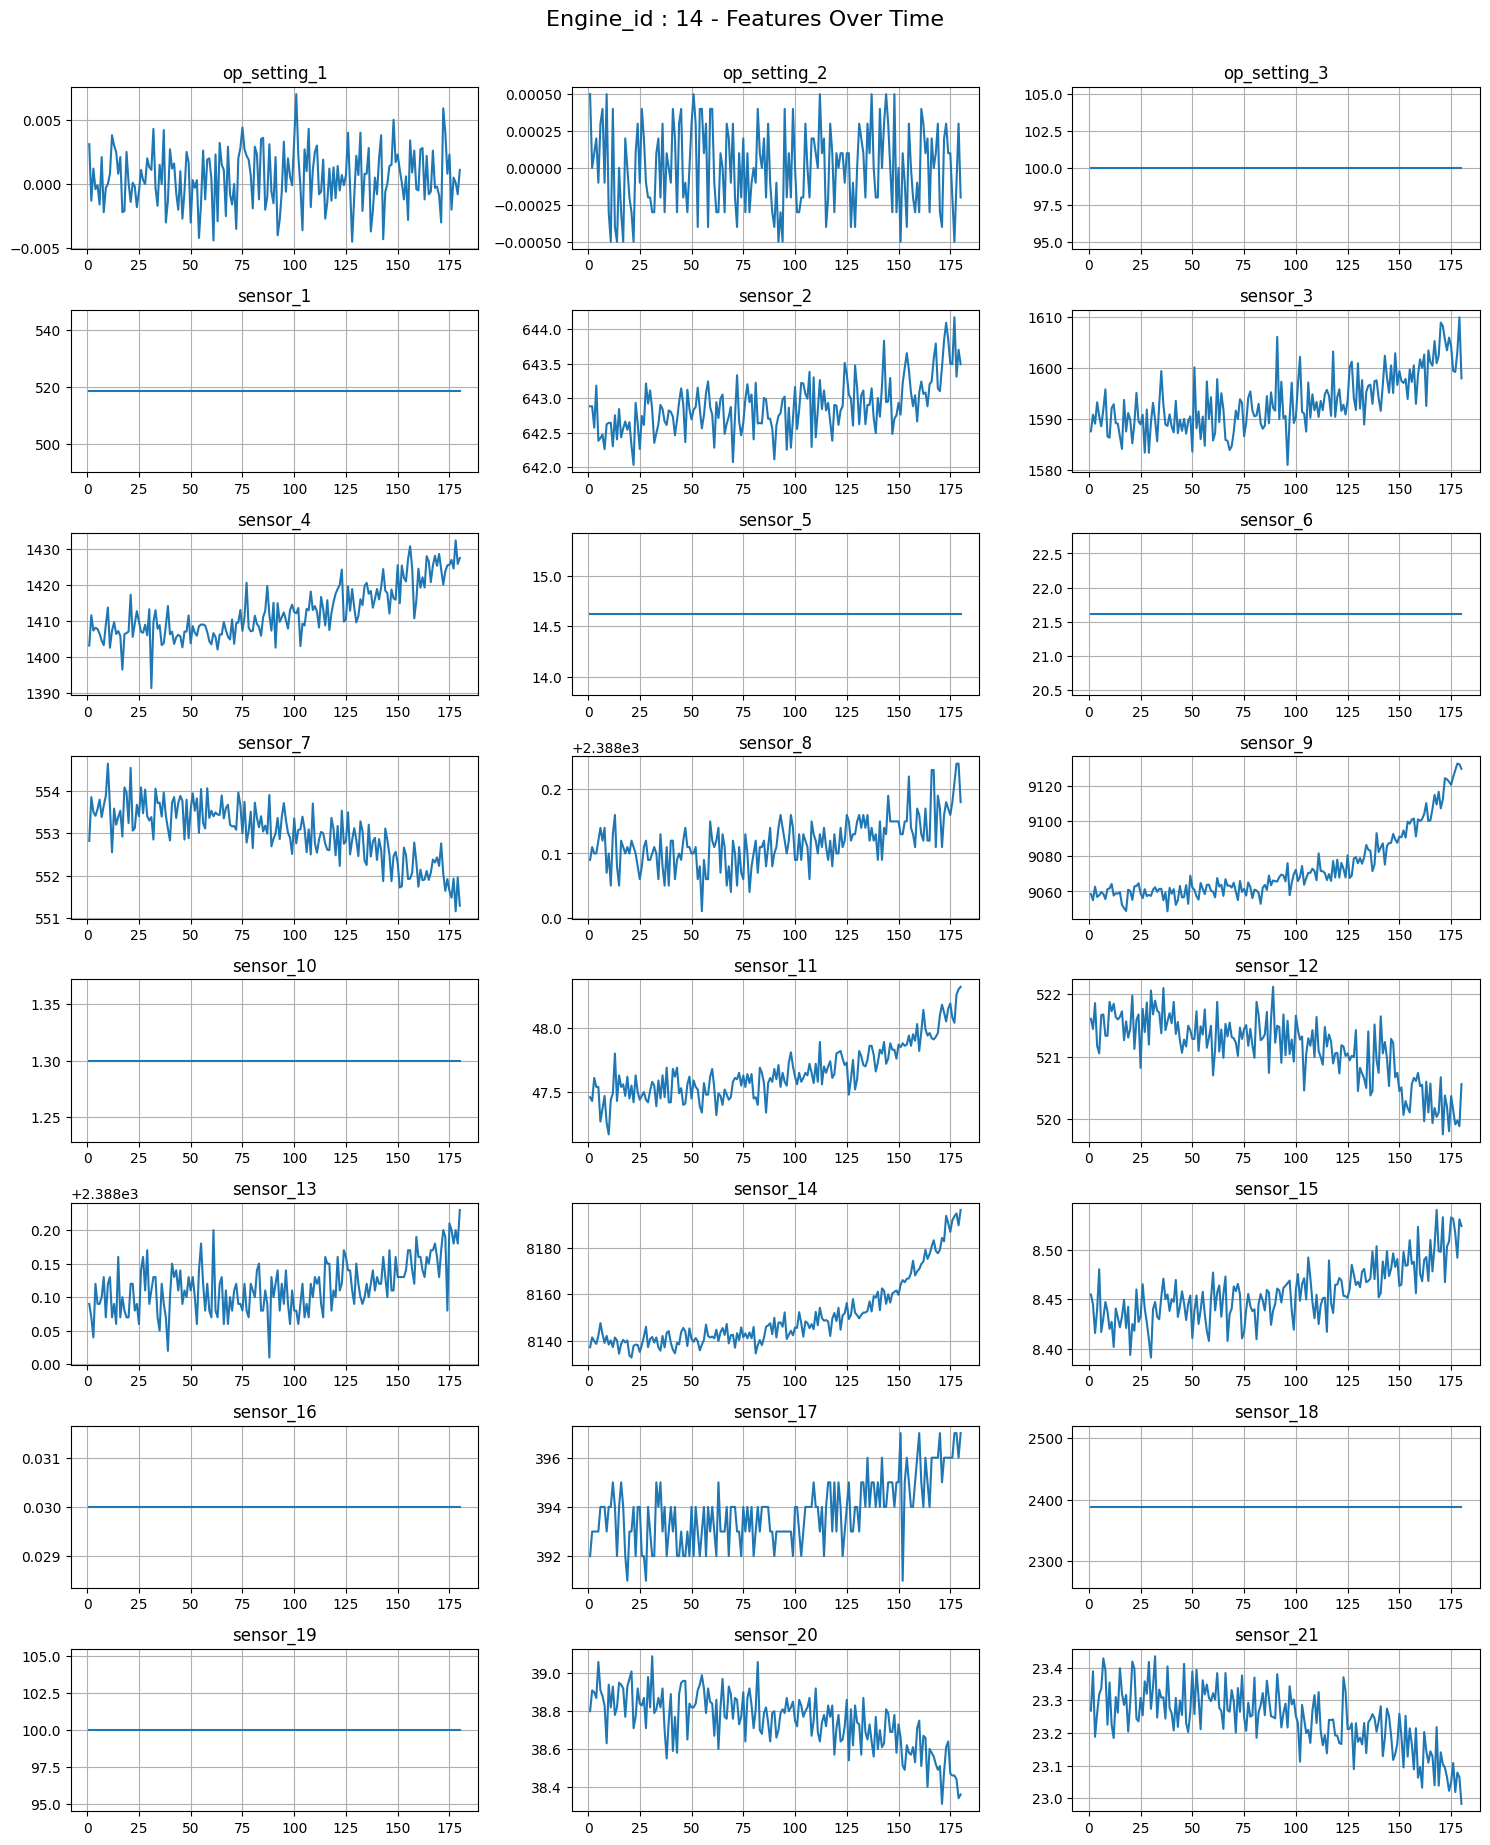

In [218]:
import matplotlib.pyplot as plt

unit_number = df_train["engine_id"].unique()[13]

unit_data = df_train[df_train["engine_id"] == unit_number]

features = unit_data.drop(["engine_id", "cycle"], axis=1)
unit_data = unit_data.set_index("cycle")

plt.figure(figsize=(15, 20))

for i, col in enumerate(features.columns, 1):
    plt.subplot(len(features.columns) // 3 + 1, 3, i)
    plt.plot(unit_data.index, unit_data[col], label=col)
    plt.title(col)
    plt.grid()
    plt.tight_layout()

plt.suptitle(f"Engine_id : {unit_number} - Features Over Time", fontsize=16, y=1.02)
plt.show()

In [219]:
#Deprecated function to smooth data
"""def smooth_data(df, window=5):
    sensor_columns = [col for col in df.columns if col.startswith('sensor_')]
    
    df_copy = df.copy() 

    for engine_id in df_copy['engine_id'].unique():
        # Filtra il subset per il motore corrente
        subset_indices = df_copy[df_copy['engine_id'] == engine_id].index
        
        for col in sensor_columns:
            smooth_mean_col_name = col
            #smooth_std_col_name = f'{col}_std'
            
            smoothed_mean_values = df_copy.loc[subset_indices, col].rolling(window=window, min_periods=1).mean()
           # smoothed_std_values = df_copy.loc[subset_indices, col].rolling(window=window, min_periods=1).std().fillna(0)
            
            df_copy.loc[subset_indices, smooth_mean_col_name] = smoothed_mean_values
            #df_copy.loc[subset_indices, smooth_std_col_name] = smoothed_std_values
    
    return df_copy"""

"def smooth_data(df, window=5):\n    sensor_columns = [col for col in df.columns if col.startswith('sensor_')]\n\n    df_copy = df.copy() \n\n    for engine_id in df_copy['engine_id'].unique():\n        # Filtra il subset per il motore corrente\n        subset_indices = df_copy[df_copy['engine_id'] == engine_id].index\n\n        for col in sensor_columns:\n            smooth_mean_col_name = col\n            #smooth_std_col_name = f'{col}_std'\n\n            smoothed_mean_values = df_copy.loc[subset_indices, col].rolling(window=window, min_periods=1).mean()\n           # smoothed_std_values = df_copy.loc[subset_indices, col].rolling(window=window, min_periods=1).std().fillna(0)\n\n            df_copy.loc[subset_indices, smooth_mean_col_name] = smoothed_mean_values\n            #df_copy.loc[subset_indices, smooth_std_col_name] = smoothed_std_values\n\n    return df_copy"

In [220]:
"""df_train = smooth_data(df_train,5)
df_test = smooth_data(df_test,5)"""

'df_train = smooth_data(df_train,5)\ndf_test = smooth_data(df_test,5)'

### 3. Creation of target RUL -Linear RUL
First, we generate the target RUL using a linear approach: for each engine, we assume that the initial RUL at the first cycle equals the engine’s maximum recorded cycle, and we decrement it by one at each subsequent cycle until it reaches zero ( fail point)

In [221]:
df_train_RUL = df_train.groupby(['engine_id']).agg({'cycle':'max'})
df_train_RUL.rename(columns={'cycle':'life'},inplace=True)
df_train=df_train.merge(df_train_RUL,how='left',on=['engine_id'])
 
df_train['RUL']=df_train['life']-df_train['cycle']
df_train.drop(['life'],axis=1,inplace=True)

In [222]:
def plot_ruls(df):

    engine_ids = df['engine_id'].unique()

    for engine_id in engine_ids:
        df_engine = df[df['engine_id'] == engine_id]
        plt.plot(df_engine['cycle'], df_engine['RUL'])

    plt.xlabel('Cycle')
    plt.ylabel('RUL (Remaining Useful Life)') 
    plt.title('Linear RUL')
    plt.legend() 
    plt.grid(True) 
    plt.show() 

C:\Users\thema\AppData\Local\Temp\ipykernel_4100\3128912281.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


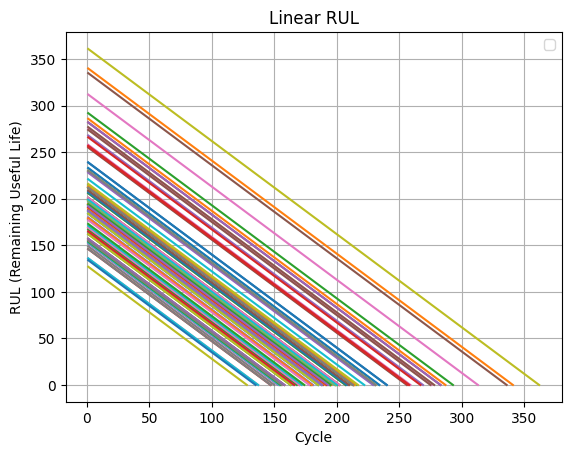

In [223]:
plot_ruls(df_train)

C:\Users\thema\AppData\Local\Temp\ipykernel_4100\3128912281.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


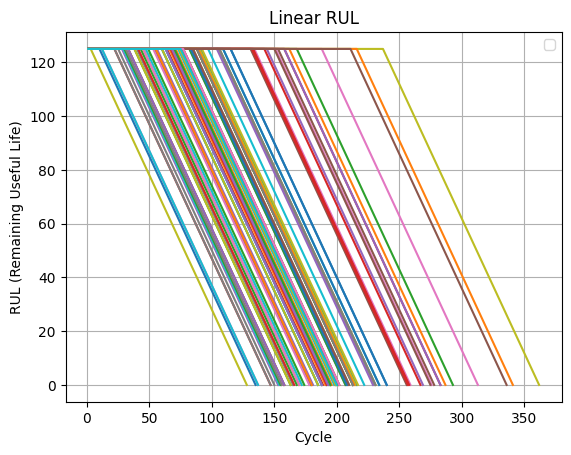

In [224]:
#clip method
df_copy = df_train.copy()
df_copy["RUL"] = df_copy["RUL"].clip(upper=125)
plot_ruls(df_copy)

### 4. Removing Costant Features

By plotting the data against cycles, we observe that some features have constant, and therefore uninformative, values. These features will be removed.

In [225]:
columns_to_drop = ['sensor_1', 'sensor_5', 'sensor_6' ,'sensor_9', 'sensor_10' ,'sensor_16', 'sensor_18', 'sensor_19','op_setting_3','op_setting_2','op_setting_1']

In [226]:
df_train = df_train.drop(columns=columns_to_drop, errors='ignore')
df_test = df_test.drop(columns=columns_to_drop, errors='ignore')


### 5. Feature Fusion using PCA
To implement our strategy, which aims to identify the point where the data begins to change significantly, indicating the onset of a failure, we move away from relying on a single sensor to detect the failure point. Instead, we use Principal Component Analysis (PCA): we utilize the first component obtained to identify the failure point


In [227]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


sensor_cols = [col for col in df_train.columns if col.startswith('sensor_')]
X = df_train[sensor_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

df_train['pca_1'] = X_pca


C:\Users\thema\AppData\Local\Temp\ipykernel_4100\342247054.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Engine ID')


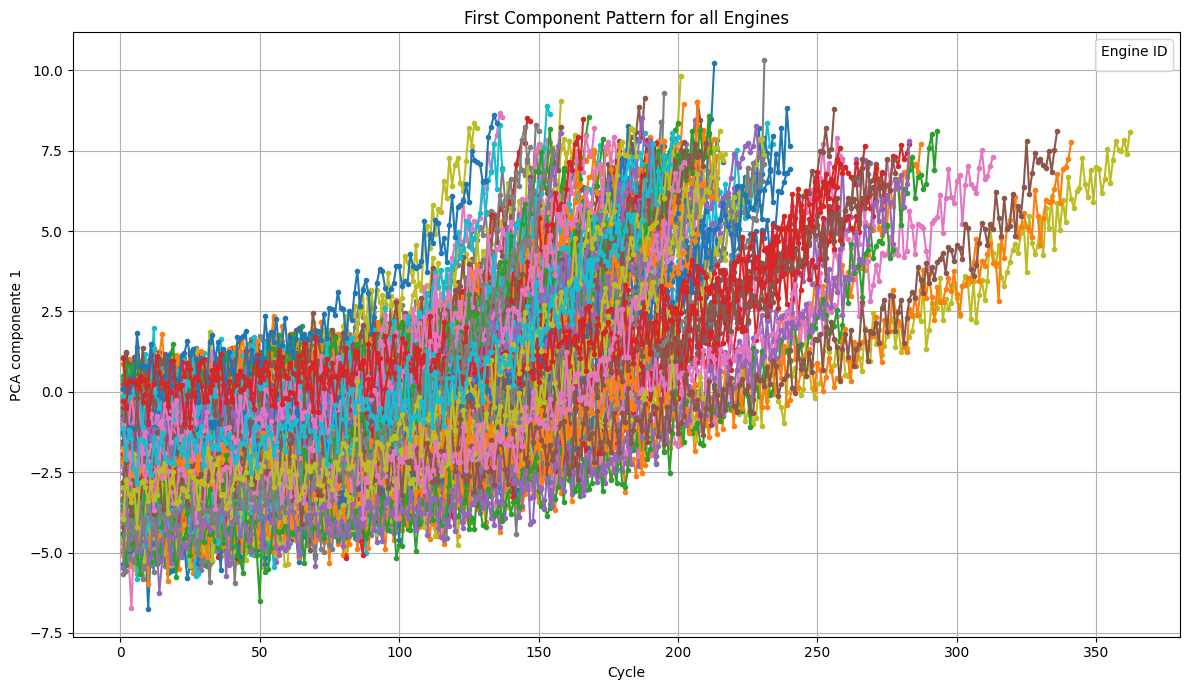

In [228]:
plt.figure(figsize=(12, 7))
for engine_id in df_train['engine_id'].unique():
    subset = df_train[df_train['engine_id'] == engine_id]
    plt.plot(subset['cycle'], subset['pca_1'], marker='.')

plt.title('First Component Pattern for all Engines')
plt.xlabel('Cycle')
plt.ylabel('PCA componente 1')
plt.legend(title='Engine ID')
plt.grid(True)
plt.tight_layout()
plt.show()

### 6. Change Point Detection


Now, for each engine in the training set, we identify the change point using the newly derived feature. To achieve this, we use the ruptures library — a Python package for offline change point detection. It provides various methods for analyzing and segmenting non-stationary signals. 

We treat the first principal component as a time-series signal using the cycles and apply the models provided by ruptures to detect the change point. 

[105, 150, 180, 192]


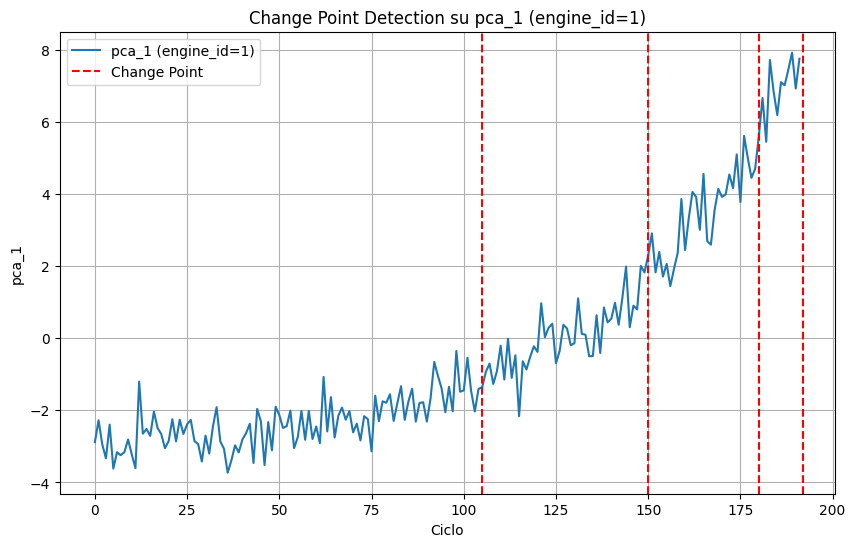

In [229]:
#example of change point detection using ruptures library for engine 1
import numpy as np
import pandas as pd
import ruptures as rpt
import matplotlib.pyplot as plt

signal = df_train[df_train['engine_id'] == 1]['pca_1'].values

# Change point detection
model = "l2" 
algo = rpt.Binseg(model=model)

algo.fit(signal)

change_points = algo.predict(n_bkps=3) 
print(change_points)

plt.figure(figsize=(10, 6))
plt.plot(signal, label="pca_1 (engine_id=1)")
for i, cp in enumerate(change_points):
    plt.axvline(cp, color="red", linestyle="--", label="Change Point" if i == 0 else "")
plt.legend()
plt.title("Change Point Detection su pca_1 (engine_id=1)")
plt.xlabel("Ciclo")
plt.ylabel("pca_1")
plt.grid(True)
plt.show()


Now using the change points identified, we limit the maximum RUL value for each engine to the corresponding change point:

In [230]:
# Assicurati che il DataFrame sia ordinato per engine_id e ciclo
df_train = df_train.sort_values(['engine_id', 'cycle'])

# Cicla per ogni engine_id
for eng_id in df_train['engine_id'].unique():
    df_engine = df_train[df_train['engine_id'] == eng_id]
    max_RUL = df_engine["RUL"].max()
    signal = df_engine['pca_1'].values

    model = "l2"  # Funzione di costo
    algo = rpt.Binseg(model=model)
    algo.fit(signal)
    change_points = algo.predict(n_bkps=3) 

    # Prendi il primo change point, se esiste
    if change_points:
        cp = change_points[0]
        # Clippa i valori di RUL per questo engine
        mask = df_train['engine_id'] == eng_id
        df_train.loc[mask, 'RUL'] = df_train.loc[mask, 'RUL'].clip(upper= ( cp))

C:\Users\thema\AppData\Local\Temp\ipykernel_4100\3128912281.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


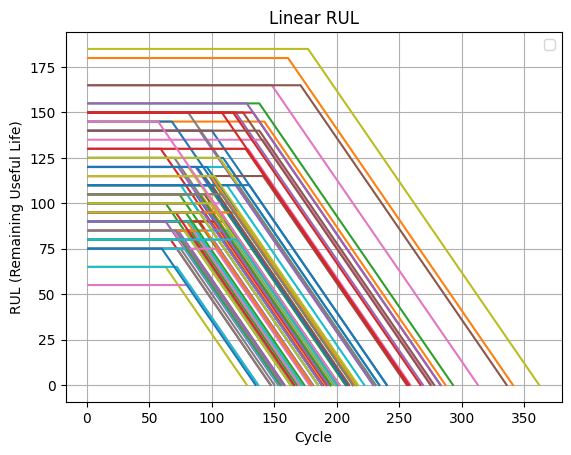

In [231]:
plot_ruls(df_train)

### 7. Labelling Test Set

In the test set, the time series ends some time before the system failure. Additionally, a vector of true Remaining Useful Life (RUL) values is provided after the testing process: we create a new test set in which each row corresponds to the last test cycle for each engine, labeled with the corresponding engine's RUL.

In [232]:
df_test = df_test.drop(columns=columns_to_drop, errors='ignore')
test_last_cycle = df_test.groupby('engine_id').agg({'cycle': 'max'}).reset_index()

df_test_last_cycle = pd.merge(test_last_cycle, df_test, how='inner', on=['engine_id', 'cycle'])

df_test_label = pd.merge(df_test_last_cycle, df_rul, how='left', on='engine_id')



### 8. File Saving

In [233]:

columns_to_drop = [col for col in df_train.columns if not col.endswith('mean') and col.endswith('_std') ]
df_train.drop(columns=columns_to_drop + ["pca_1"], inplace=True )
df_test_label.drop(columns=columns_to_drop, inplace=True )


In [234]:
df_train.to_csv('pre_processed_dataset/train.csv', index=False)
df_test_label.to_csv('pre_processed_dataset/test.csv', index=False)


### 9. Train and Test sets creation for LSTM


In [235]:
from sklearn.preprocessing import MinMaxScaler


df_train_scaled = df_train.copy()
df_test_scaled = df_test.copy()

sensor_cols = [col for col in df_train.columns if col.startswith("sensor_")]

x_scaler = MinMaxScaler()
x_scaler.fit(df_train[sensor_cols])

df_train[sensor_cols] = x_scaler.transform(df_train[sensor_cols])
df_test[sensor_cols] = x_scaler.transform(df_test[sensor_cols])

In [236]:
import numpy as np

def create_sliding_window(df, window_size=5):
    X, y = [], []
    sensor_cols = [col for col in df.columns if col.startswith("sensor_")]

    for engine_id in df['engine_id'].unique():
        engine_data = df[df['engine_id'] == engine_id].sort_values(by='cycle')
        rul_values = engine_data['RUL'].values

        for i in range(len(engine_data) - window_size + 1):
            window = engine_data.iloc[i:i+window_size]
            features = window[sensor_cols].values

            target = rul_values[i + window_size - 1]

            X.append(features)
            y.append(target)

    return np.array(X), np.array(y)



In [237]:
X_train,y_train = create_sliding_window(df_train,window_size=30)

In [238]:
df_test_RUL = pd.merge(df_test, df_rul, how='left', on='engine_id')

In [239]:
import numpy as np

def extract_last_5_cycles(df, window_size=5):
    X_test = []
    y_test = []
    sensor_cols = [col for col in df.columns if col.startswith("sensor_")]

    for engine_id in df['engine_id'].unique():
        engine_data = df[df['engine_id'] == engine_id].sort_values(by='cycle')
        last_window = engine_data.iloc[-window_size:][sensor_cols].values

        if len(last_window) < window_size:
            padding = np.zeros((window_size - len(last_window), len(sensor_cols)))
            last_window = np.vstack((padding, last_window))

        X_test.append(last_window)

        rul_value = engine_data.iloc[-1]['RUL']
        y_test.append(rul_value)

    return np.array(X_test), np.array(y_test)

In [240]:
X_test,y_test = extract_last_5_cycles(df_test_RUL,window_size=30)

In [241]:
np.savez("rul_data.npz",
         X_train=X_train,
         y_train=y_train,
         X_test=X_test,
         y_test=y_test)